# MediQwen Semantic Scope Classifier Pipeline

This notebook provides the prototype, evaluation suite, and production-ready decision gate for the MediQwen Semantic Scope Classifier (scope_classifier).

## Cell 1 — Imports & Environment Setup

In [1]:

import sys
import os
from pathlib import Path

# Resolve project root (one level up from notebooks/)
PROJECT_ROOT = Path("../").resolve()

# Add project root to Python path if not present
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"✅ Project root added to sys.path: {PROJECT_ROOT}")
print(f"📁 Project root  : {PROJECT_ROOT}")
print(f"📁 Working dir   : {Path.cwd()}")
print("🩺 MediQwen Semantic Scope Classifier")
print("==================================================")

from src.models.embeddings import initialize_embeddings, normalize_vectors

# Initialize using your codebase's existing loader
hf_embeddings = initialize_embeddings()
print("✅ Project embeddings loaded successfully!")



✅ Project root added to sys.path: C:\santosh\MediQwen
📁 Project root  : C:\santosh\MediQwen
📁 Working dir   : c:\santosh\MediQwen\notebooks
🩺 MediQwen Semantic Scope Classifier


c:\santosh\MediQwen\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


🔍 Initializing embedding model: BAAI/bge-large-en-v1.5
🔧 Using device: auto


Loading weights: 100%|██████████| 391/391 [00:00<00:00, 2567.32it/s]


✅ Project embeddings loaded successfully!


## Cell 2 — Define Prototype Datasets
Defines initial prototype vectors for cosine similarity computation across target categories (MEDICAL, NUTRITION, CASUAL, OUT_OF_SCOPE).


In [2]:
SCOPE_PROTOTYPES = {
    "MEDICAL": [
        "What are the treatment options for this condition?",
        "What could be causing this symptom?",
        "Why does my skin itch?",
        "Should I see a doctor?",
        "What are the warning signs?",
        "How can I manage this condition?",
        "What medications are commonly used?",
        "Is this symptom serious?",
        "What can I do to relieve these symptoms?",
        "What are the possible causes?",
        "How is this diagnosed?",
        "What are the complications of this illness?",
        "When should I seek medical help?",
        "What are the side effects of this medication?",
        "How can I prevent this condition from worsening?",
        "How can i cure this condition?",
        "What are the home remedies for this symptom?",
    ],
    "NUTRITION": [
        "What is a healthy diet?",
        "What foods are good for heart health?",
        "What should I eat to get more protein?",
        "What foods should I avoid?",
        "Can you suggest a healthy meal?",
        "How can I improve my diet?",
        "What nutrients do I need?",
        "What are healthy foods for breakfast?",
        "How much protein should I eat?",
        "What is a balanced diet?",
        "How do I read a nutrition label?",
        "How much protein is in one egg?",
        "What are the benefits of eating vegetables?",
        "What are the best sources of vitamin C?",
        "Importance of hydration and drinking water.",
        "What are the important sources of zinc?"
    ],
    "CASUAL": [
        "How are you?",
        "Good morning.",
        "Let's chat.",
        "What can you do?",
        "How is your day?",
        "What's something fun to talk about?",
        "Can we have a conversation?",
        "Hello",
        "Hy there",
        "Nice to meet you!",
        "Thank you very much",
        "Okay sounds good",
        "Tell me about yourself.",
        "What are your capabilities?",
        "Who are you?",
        "What can you help me with?",
    ],
    "OUT_OF_SCOPE": [
        "Write Python code for a game.",
        "Explain quantum computing.",
        "Help me configure a Linux server.",
        "Write a marketing strategy.",
        "How do I build a website?",
        "Help me debug this JavaScript code.",
        "Explain how a car engine works.",
        "Write a Python web scraper.",
        "Help me with my programming assignment.",
        "Explain computer networking.",
        "What is the stock market trend today?",
        "Who won the football game?",
        "Tell me a joke.",
        "Tell me a story.",
        "Who won the election?",
        "What is the weather like today?",
    ],
}

## Cell 3 — Generate & Cache Prototype Embeddings
Computes L2-normalized BGE embeddings for category prototypes and caches matrices locally for similarity lookups.

In [3]:
import numpy as np

# BAAI/bge-large-en-v1.5 performs better when queries have instructions or normalized embeddings
prototype_embeddings = {}

for scope, examples in SCOPE_PROTOTYPES.items():
    # Embed using LangChain HuggingFace interface
    raw_vecs = hf_embeddings.embed_documents(examples)
    norm_vecs = normalize_vectors(np.array(raw_vecs))
    prototype_embeddings[scope] = norm_vecs
    print(f"Scope: {scope:<12} | Matrix Shape: {norm_vecs.shape}")

Scope: MEDICAL      | Matrix Shape: (17, 1024)
Scope: NUTRITION    | Matrix Shape: (16, 1024)
Scope: CASUAL       | Matrix Shape: (16, 1024)
Scope: OUT_OF_SCOPE | Matrix Shape: (16, 1024)


## Cell 4 — Define Cosine Classifier Function
Implements cosine classification, score confidence margins, and fallback routing.

In [4]:
import time

def classify_scope_semantic(query: str):
    start_time = time.perf_counter()

    raw_query = hf_embeddings.embed_query(query)
    query_vec = normalize_vectors(np.array([raw_query]))[0]

    scores = {}

    for scope, emb_matrix in prototype_embeddings.items():
        sims = emb_matrix @ query_vec
        scores[scope] = float(np.max(sims))

    ranked = sorted(
        scores.items(),
        key=lambda x: x[1],
        reverse=True
    )

    best_scope, best_score = ranked[0]
    second_scope, second_score = ranked[1]

    margin = best_score - second_score
    elapsed_ms = (time.perf_counter() - start_time) * 1000

    return {
        "query": query,
        "best_scope": best_scope,
        "best_score": round(best_score, 4),
        "second_scope": second_scope,
        "second_score": round(second_score, 4),
        "margin": round(margin, 4),
        "scores": {k: round(v, 4) for k, v in scores.items()},
        "latency_ms": round(elapsed_ms, 2),
    }

## Cell 5 — Expanded Benchmark Dataset

Following the calibration plan: 30 MEDICAL / 20 NUTRITION / 20 CASUAL / 30 OUT_OF_SCOPE, deliberately including short follow-up queries, context-dependent phrasing, and context-switch / adversarial cases (medical vocabulary wrapped in a non-medical intent).

In [6]:
from collections import Counter

BENCHMARK = [
    # =========================================================================
    # 1. MEDICAL (Total: 40 | Standalone: 20 | Contextual/Ambiguous: 20)
    # =========================================================================
    # --- MEDICAL: Standalone (20) ---
    ("What are the symptoms of vitamin B12 deficiency?", "MEDICAL", "STANDALONE"),
    ("What are the main causes of shortness of breath?", "MEDICAL", "STANDALONE"),
    ("Is high blood pressure reversible?", "MEDICAL", "STANDALONE"),
    ("How is type 2 diabetes managed?", "MEDICAL", "STANDALONE"),
    ("What should I eat after a heart attack?", "MEDICAL", "STANDALONE"),
    ("What are the early signs of a stroke?", "MEDICAL", "STANDALONE"),
    ("Can stress cause chest tightness?", "MEDICAL", "STANDALONE"),
    ("What side effects does amoxicillin have?", "MEDICAL", "STANDALONE"),
    ("How long is an ear infection contagious?", "MEDICAL", "STANDALONE"),
    ("What is the difference between cold and flu?", "MEDICAL", "STANDALONE"),
    ("When is a fever considered dangerously high?", "MEDICAL", "STANDALONE"),
    ("What triggers asthma attacks?", "MEDICAL", "STANDALONE"),
    ("What causes sharp pain in the lower right abdomen?", "MEDICAL", "STANDALONE"),
    ("How can I lower my cholesterol level naturally?", "MEDICAL", "STANDALONE"),
    ("What are the long-term effects of untreated hypertension?", "MEDICAL", "STANDALONE"),
    ("Is a resting heart rate of 95 normal?", "MEDICAL", "STANDALONE"),
    ("What are the common triggers for migraine headaches?", "MEDICAL", "STANDALONE"),
    ("How do I distinguish between reflux and heart pain?", "MEDICAL", "STANDALONE"),
    ("What are the clinical signs of severe dehydration?", "MEDICAL", "STANDALONE"),
    ("Can hypothyroidism cause unexplained weight gain?", "MEDICAL", "STANDALONE"),

    # --- MEDICAL: Contextual / Ambiguous (20) ---
    ("what should I do about this?", "MEDICAL", "CONTEXTUAL"),
    ("could this be serious?", "MEDICAL", "CONTEXTUAL"),
    ("what causes it?", "MEDICAL", "CONTEXTUAL"),
    ("what are the early symptoms of this?", "MEDICAL", "CONTEXTUAL"),
    ("what happens if I leave it untreated?", "MEDICAL", "CONTEXTUAL"),
    ("what about treatment?", "MEDICAL", "CONTEXTUAL"),
    ("how long does recovery usually take?", "MEDICAL", "CONTEXTUAL"),
    ("is this contagious?", "MEDICAL", "CONTEXTUAL"),
    ("Will this rash spread to other areas?", "MEDICAL", "CONTEXTUAL"),
    ("Is there an over-the-counter cure for this?", "MEDICAL", "CONTEXTUAL"),
    ("treatments?", "MEDICAL", "AMBIGUOUS"),
    ("how can I make it better?", "MEDICAL", "AMBIGUOUS"),
    ("is this something I should worry about?", "MEDICAL", "AMBIGUOUS"),
    ("how do I manage this?", "MEDICAL", "AMBIGUOUS"),
    ("what should I do now?", "MEDICAL", "AMBIGUOUS"),
    ("can this get worse?", "MEDICAL", "AMBIGUOUS"),
    ("is this dangerous?", "MEDICAL", "AMBIGUOUS"),
    ("what are my options?", "MEDICAL", "AMBIGUOUS"),
    ("What should I do?", "MEDICAL", "AMBIGUOUS"),
    ("is it getting worse?", "MEDICAL", "AMBIGUOUS"),

    # =========================================================================
    # 2. NUTRITION (Total: 30 | Standalone: 25 | Contextual/Ambiguous: 5)
    # =========================================================================
    # --- NUTRITION: Standalone (25) ---
    ("what should I eat for a healthy heart?", "NUTRITION", "STANDALONE"),
    ("what foods contain high vitamin D?", "NUTRITION", "STANDALONE"),
    ("Is intermittent fasting healthy?", "NUTRITION", "STANDALONE"),
    ("What are good sources of fiber?", "NUTRITION", "STANDALONE"),
    ("How many calories should I eat per day?", "NUTRITION", "STANDALONE"),
    ("What snacks are healthy for weight loss?", "NUTRITION", "STANDALONE"),
    ("Are carbs bad for me?", "NUTRITION", "STANDALONE"),
    ("What vitamins should I take daily?", "NUTRITION", "STANDALONE"),
    ("What foods help lower cholesterol?", "NUTRITION", "STANDALONE"),
    ("Should I cut down on sugar?", "NUTRITION", "STANDALONE"),
    ("What diet is recommended for diabetes?", "NUTRITION", "STANDALONE"),
    ("Can food help with high blood pressure?", "NUTRITION", "STANDALONE"),
    ("What foods contain vitamin B12?", "NUTRITION", "STANDALONE"),
    ("What should I eat if I have anemia?", "NUTRITION", "STANDALONE"),
    ("Are plant-based proteins as effective as whey?", "NUTRITION", "STANDALONE"),
    ("What foods increase gut microbiome diversity?", "NUTRITION", "STANDALONE"),
    ("How much sodium is allowed in a low-salt diet?", "NUTRITION", "STANDALONE"),
    ("What are the health benefits of Mediterranean diet?", "NUTRITION", "STANDALONE"),
    ("Should I drink electrolyte water after workouts?", "NUTRITION", "STANDALONE"),
    ("What foods contain healthy fats like omega-3?", "NUTRITION", "STANDALONE"),
    ("Is intake of artificial sweeteners harmful?", "NUTRITION", "STANDALONE"),
    ("What are good iron-rich foods for vegetarians?", "NUTRITION", "STANDALONE"),
    ("How does meal timing affect metabolism?", "NUTRITION", "STANDALONE"),
    ("What foods help prevent muscle loss during fasting?", "NUTRITION", "STANDALONE"),
    ("Is eating whole fruit better than drinking fruit juice?", "NUTRITION", "STANDALONE"),

    # --- NUTRITION: Contextual / Ambiguous (5) ---
    ("Is this meal balanced enough?", "NUTRITION", "CONTEXTUAL"),
    ("How many calories are in this snack?", "NUTRITION", "CONTEXTUAL"),
    ("Should I avoid eating this at night?", "NUTRITION", "CONTEXTUAL"),
    ("Is this bad for my cholesterol?", "NUTRITION", "CONTEXTUAL"),
    ("Will this help me hit my daily protein goal?", "NUTRITION", "CONTEXTUAL"),

    # =========================================================================
    # 3. CASUAL (Total: 30 | Standalone: 25 | Contextual/Ambiguous: 5)
    # =========================================================================
    # --- CASUAL: Standalone (25) ---
    ("hello how are you", "CASUAL", "STANDALONE"),
    ("thank you for your advice", "CASUAL", "STANDALONE"),
    ("What's your favorite thing to talk about?", "CASUAL", "STANDALONE"),
    ("See you later", "CASUAL", "STANDALONE"),
    ("That's helpful, thanks", "CASUAL", "STANDALONE"),
    ("What's up?", "CASUAL", "STANDALONE"),
    ("Good night", "CASUAL", "STANDALONE"),
    ("Have a great afternoon!", "CASUAL", "STANDALONE"),
    ("I'm feeling bored today.", "CASUAL", "STANDALONE"),
    ("Can you sing a song?", "CASUAL", "STANDALONE"),
    ("Are you an AI or a real human?", "CASUAL", "STANDALONE"),
    ("What is your name?", "CASUAL", "STANDALONE"),
    ("Hey there, how is it going?", "CASUAL", "STANDALONE"),
    ("I appreciate your quick answer.", "CASUAL", "STANDALONE"),
    ("Hope you have a wonderful day!", "CASUAL", "STANDALONE"),
    ("Is anyone there?", "CASUAL", "STANDALONE"),
    ("Thanks a lot for the help.", "CASUAL", "STANDALONE"),
    ("Catch you later!", "CASUAL", "STANDALONE"),
    ("Glad to hear that.", "CASUAL", "STANDALONE"),
    ("That makes sense to me.", "CASUAL", "STANDALONE"),
    ("Awesome, thanks!", "CASUAL", "STANDALONE"),
    ("Nice talking to you.", "CASUAL", "STANDALONE"),
    ("No problem at all.", "CASUAL", "STANDALONE"),
    ("Sounds good to me!", "CASUAL", "STANDALONE"),
    ("Have a good weekend!", "CASUAL", "STANDALONE"),

    # --- CASUAL: Contextual / Ambiguous (5) ---
    ("What do you mean by that?", "CASUAL", "CONTEXTUAL"),
    ("Can you say that again?", "CASUAL", "CONTEXTUAL"),
    ("That sounds cool!", "CASUAL", "CONTEXTUAL"),
    ("Why did you say that?", "CASUAL", "CONTEXTUAL"),
    ("Alright, let's keep talking.", "CASUAL", "CONTEXTUAL"),

    # =========================================================================
    # 4. OUT_OF_SCOPE (Total: 40 | Standalone: 40 | Contextual/Ambiguous: 0)
    # =========================================================================
    # --- OUT_OF_SCOPE: General / Non-Medical (20) ---
    ("write Python code", "OUT_OF_SCOPE", "STANDALONE"),
    ("debug this JavaScript", "OUT_OF_SCOPE", "STANDALONE"),
    ("explain quantum mechanics", "OUT_OF_SCOPE", "STANDALONE"),
    ("help me configure Docker", "OUT_OF_SCOPE", "STANDALONE"),
    ("write a web scraper", "OUT_OF_SCOPE", "STANDALONE"),
    ("create a game", "OUT_OF_SCOPE", "STANDALONE"),
    ("explain stock trading", "OUT_OF_SCOPE", "STANDALONE"),
    ("help me design a website", "OUT_OF_SCOPE", "STANDALONE"),
    ("Recommend a good sci-fi movie.", "OUT_OF_SCOPE", "STANDALONE"),
    ("Help me plan a vacation itinerary.", "OUT_OF_SCOPE", "STANDALONE"),
    ("Translate this sentence into French.", "OUT_OF_SCOPE", "STANDALONE"),
    ("Who created you?", "OUT_OF_SCOPE", "STANDALONE"),
    ("Tell me a fun fact about space.", "OUT_OF_SCOPE", "STANDALONE"),
    ("How do I fix a broken car air conditioner?", "OUT_OF_SCOPE", "STANDALONE"),
    ("Explain the history of the French Revolution.", "OUT_OF_SCOPE", "STANDALONE"),
    ("What is the capital of Australia?", "OUT_OF_SCOPE", "STANDALONE"),
    ("How do I replace a flat tire on a sedan?", "OUT_OF_SCOPE", "STANDALONE"),
    ("Can you write a bash script to organize local files?", "OUT_OF_SCOPE", "STANDALONE"),
    ("What are the rules of chess?", "OUT_OF_SCOPE", "STANDALONE"),
    ("How does guitar amplification work?", "OUT_OF_SCOPE", "STANDALONE"),

    # --- OUT_OF_SCOPE: Adversarial / Medical-Topic (20) ---
    ("Tell me a joke about psoriasis.", "OUT_OF_SCOPE", "STANDALONE"),
    ("Make a joke about hospitals.", "OUT_OF_SCOPE", "STANDALONE"),
    ("Explain psoriasis as a character in a novel.", "OUT_OF_SCOPE", "STANDALONE"),
    ("Write a poem about a hospital nurse.", "OUT_OF_SCOPE", "STANDALONE"),
    ("Tell me a funny story about a doctor.", "OUT_OF_SCOPE", "STANDALONE"),
    ("Write Python code to analyze hives.", "OUT_OF_SCOPE", "STANDALONE"),
    ("Build a web scraper for clinical guidelines.", "OUT_OF_SCOPE", "STANDALONE"),
    ("write Python code to analyze this", "OUT_OF_SCOPE", "STANDALONE"),
    ("write a scraper for this condition", "OUT_OF_SCOPE", "STANDALONE"),
    ("explain quantum computing using this medical example", "OUT_OF_SCOPE", "STANDALONE"),
    ("generate HTML for this diagnosis", "OUT_OF_SCOPE", "STANDALONE"),
    ("Write Python code to calculate BMI.", "OUT_OF_SCOPE", "STANDALONE"),
    ("Create a Python program for a medical chatbot.", "OUT_OF_SCOPE", "STANDALONE"),
    ("Build a machine learning model to classify skin lesions.", "OUT_OF_SCOPE", "STANDALONE"),
    ("Write code to detect pneumonia from X-rays.", "OUT_OF_SCOPE", "STANDALONE"),
    ("Write a story about a doctor treating a dragon.", "OUT_OF_SCOPE", "STANDALONE"),
    ("Write a Python program about diabetes statistics.", "OUT_OF_SCOPE", "STANDALONE"),
    ("Build a React dashboard for hospital patient records.", "OUT_OF_SCOPE", "STANDALONE"),
    ("Write a SQL query to extract patient symptom data.", "OUT_OF_SCOPE", "STANDALONE"),
    ("Explain the physics of MRI magnet resonance.", "OUT_OF_SCOPE", "STANDALONE"),
]

print(f"Total: {len(BENCHMARK)}")
print("By label:    ", Counter(l for _, l, _ in BENCHMARK))
print("By test_type:", Counter(t for _, _, t in BENCHMARK))

Total: 140
By label:     Counter({'MEDICAL': 40, 'OUT_OF_SCOPE': 40, 'NUTRITION': 30, 'CASUAL': 30})
By test_type: Counter({'STANDALONE': 110, 'CONTEXTUAL': 20, 'AMBIGUOUS': 10})


## Cell 6 — Run Classifier Over the Benchmark

In [7]:
import pandas as pd
import numpy as np

results = []
for query, true_label, test_label in BENCHMARK:
    res = classify_scope_semantic(query)
    results.append({
        "Query": query,
        "True Label": true_label,
        "Test Label": test_label,
        "Predicted": res["best_scope"],
        "Correct": res["best_scope"] == true_label,
        "Score": res["best_score"],
        "Second Scope": res["second_scope"],
        "Margin": res["margin"],
        "MEDICAL Sim": res["scores"]["MEDICAL"],
        "NUTRITION Sim": res["scores"]["NUTRITION"],
        "CASUAL Sim": res["scores"]["CASUAL"],
        "OOS Sim": res["scores"]["OUT_OF_SCOPE"],
        "Latency (ms)": res["latency_ms"],
    })

df_bench = pd.DataFrame(results)
overall_acc = df_bench["Correct"].mean()
print(f"Overall accuracy on {len(df_bench)} queries: {overall_acc:.2%}")
df_bench.head(10)


Overall accuracy on 140 queries: 92.86%


,Query,True Label,Test Label,Predicted,Correct,Score,Second Scope,Margin,MEDICAL Sim,NUTRITION Sim,CASUAL Sim,OOS Sim,Latency (ms)
0,What are the symptoms of vitamin B12 deficiency?,MEDICAL,STANDALONE,MEDICAL,True,0.6227,NUTRITION,0.0503,0.6227,0.5724,0.4322,0.4230,243.30
1,What are the main causes of shortness of breath?,MEDICAL,STANDALONE,MEDICAL,True,0.6566,NUTRITION,0.2003,0.6566,0.4564,0.3987,0.3737,92.37
2,Is high blood pressure reversible?,MEDICAL,STANDALONE,MEDICAL,True,0.5054,NUTRITION,0.0204,0.5054,0.4850,0.4356,0.4100,86.89
3,How is type 2 diabetes managed?,MEDICAL,STANDALONE,MEDICAL,True,0.6070,NUTRITION,0.0692,0.6070,0.5378,0.5141,0.4306,79.44
4,What should I eat after a heart attack?,MEDICAL,STANDALONE,NUTRITION,False,0.7898,MEDICAL,0.2156,0.5742,0.7898,0.5144,0.4090,84.50
5,What are the early signs of a stroke?,MEDICAL,STANDALONE,MEDICAL,True,0.6336,NUTRITION,0.1562,0.6336,0.4774,0.4455,0.4203,87.20
6,Can stress cause chest tightness?,MEDICAL,STANDALONE,MEDICAL,True,0.6156,NUTRITION,0.1185,0.6156,0.4970,0.3934,0.3668,77.91
7,What side effects does amoxicillin have?,MEDICAL,STANDALONE,MEDICAL,True,0.7461,NUTRITION,0.2546,0.7461,0.4915,0.4018,0.3597,88.34
8,How long is an ear infection contagious?,MEDICAL,STANDALONE,MEDICAL,True,0.4487,CASUAL,0.0269,0.4487,0.3944,0.4218,0.3884,83.58
9,What is the difference between cold and flu?,MEDICAL,STANDALONE,MEDICAL,True,0.4579,NUTRITION,0.0087,0.4579,0.4492,0.4097,0.4461,85.68


In [8]:
# Analyze benchmark results by test label
df_bench.groupby("Test Label")["Correct"].agg(
    ["count", "sum", "mean"]
)

,count,sum,mean
Test Label,,,
AMBIGUOUS,10,6,0.600000
CONTEXTUAL,20,20,1.000000
STANDALONE,110,104,0.945455


In [9]:
# Display ambiguous queries sorted by margin (lowest to highest)
df_ambiguous = (
    df_bench[df_bench["Test Label"] == "AMBIGUOUS"]
    .sort_values("Margin")
)

display(
    df_ambiguous[
        ["Query", "True Label", "Predicted", "Score", "Margin", "Correct"]
    ]
)

,Query,True Label,Predicted,Score,Margin,Correct
31,how can I make it better?,MEDICAL,NUTRITION,0.6958,0.0308,False
38,What should I do?,MEDICAL,CASUAL,0.7683,0.0422,False
37,what are my options?,MEDICAL,CASUAL,0.7812,0.0428,False
34,what should I do now?,MEDICAL,CASUAL,0.7332,0.0673,False
36,is this dangerous?,MEDICAL,MEDICAL,0.6989,0.1207,True
39,is it getting worse?,MEDICAL,MEDICAL,0.7374,0.1286,True
30,treatments?,MEDICAL,MEDICAL,0.7765,0.1387,True
32,is this something I should worry about?,MEDICAL,MEDICAL,0.7497,0.1534,True
35,can this get worse?,MEDICAL,MEDICAL,0.7899,0.1678,True
33,how do I manage this?,MEDICAL,MEDICAL,0.8873,0.2002,True


## Cell 7: Misclassified queries are the most useful signal for threshold/margin tuning — inspect them directly:

In [10]:
# Analyze misclassified queries sorted by margin (lowest to highest)
df_errors = df_bench[~df_bench["Correct"]].sort_values("Margin")
print(f"{len(df_errors)} misclassified out of {len(df_bench)}")
df_errors[["Query", "True Label", "Predicted", "Score", "Margin"]]


10 misclassified out of 140


,Query,True Label,Predicted,Score,Margin
110,Translate this sentence into French.,OUT_OF_SCOPE,CASUAL,0.5148,0.0079
112,Tell me a fun fact about space.,OUT_OF_SCOPE,CASUAL,0.6323,0.0115
31,how can I make it better?,MEDICAL,NUTRITION,0.6958,0.0308
130,generate HTML for this diagnosis,OUT_OF_SCOPE,MEDICAL,0.6523,0.0370
38,What should I do?,MEDICAL,CASUAL,0.7683,0.0422
37,what are my options?,MEDICAL,CASUAL,0.7812,0.0428
13,How can I lower my cholesterol level naturally?,MEDICAL,NUTRITION,0.6689,0.0578
34,what should I do now?,MEDICAL,CASUAL,0.7332,0.0673
4,What should I eat after a heart attack?,MEDICAL,NUTRITION,0.7898,0.2156
111,Who created you?,OUT_OF_SCOPE,CASUAL,0.7654,0.2500


## Cell 8 — Confusion Matrix

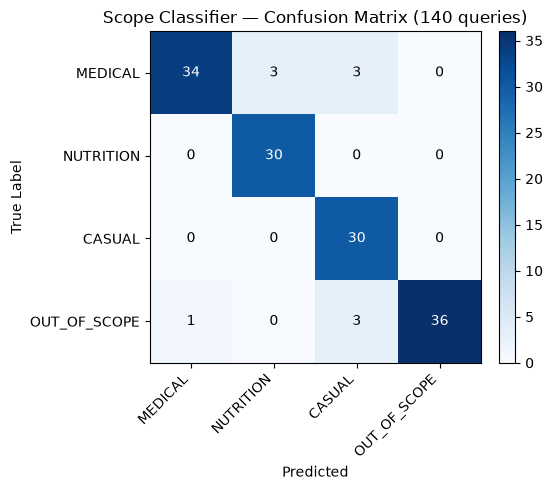

              precision    recall  f1-score   support

     MEDICAL       0.97      0.85      0.91        40
   NUTRITION       0.91      1.00      0.95        30
      CASUAL       0.83      1.00      0.91        30
OUT_OF_SCOPE       1.00      0.90      0.95        40

    accuracy                           0.93       140
   macro avg       0.93      0.94      0.93       140
weighted avg       0.94      0.93      0.93       140



In [11]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt

labels_order = ["MEDICAL", "NUTRITION", "CASUAL", "OUT_OF_SCOPE"]
cm = confusion_matrix(df_bench["True Label"], df_bench["Predicted"], labels=labels_order)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(labels_order)))
ax.set_yticks(range(len(labels_order)))
ax.set_xticklabels(labels_order, rotation=45, ha="right")
ax.set_yticklabels(labels_order)
ax.set_xlabel("Predicted")
ax.set_ylabel("True Label")
ax.set_title(
    f"Scope Classifier — Confusion Matrix ({len(df_bench)} queries)"
)
for i in range(len(labels_order)):
    for j in range(len(labels_order)):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black")

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

print(classification_report(df_bench["True Label"], df_bench["Predicted"], labels=labels_order))


## Cell 9 — Threshold × Margin Grid Search

For each (confidence, margin) pair, a query is only auto-resolved when it is `CONFIDENT`; `UNCERTAIN` queries are meant to fall through to the context resolver rather than being scored right/wrong here. So the metrics we actually care about are: **accuracy among CONFIDENT predictions** (never trust a confident answer that's wrong) and **coverage** (don't push so many queries to UNCERTAIN that the context resolver is doing all the work).

In [12]:
confidence_grid = [0.50, 0.55, 0.60, 0.65, 0.70]
margin_grid = [0.00, 0.03, 0.05, 0.10]

grid_rows = []
for conf_t in confidence_grid:
    for margin_t in margin_grid:
        is_confident = (df_bench["Score"] >= conf_t) & (df_bench["Margin"] >= margin_t)
        n_confident = is_confident.sum()
        coverage = n_confident / len(df_bench)

        if n_confident > 0:
            confident_acc = df_bench.loc[is_confident, "Correct"].mean()
            # the failure mode we most want to avoid: a CONFIDENT wrong answer
            n_confident_wrong = (is_confident & ~df_bench["Correct"]).sum()
        else:
            confident_acc = float("nan")
            n_confident_wrong = 0

        grid_rows.append({
            "Confidence Threshold": conf_t,
            "Margin Threshold": margin_t,
            "Coverage": round(coverage, 3),
            "Confident Accuracy": round(confident_acc, 3) if n_confident else None,
            "Confident-but-Wrong (count)": n_confident_wrong,
        })

df_grid = pd.DataFrame(grid_rows)

# Rank candidates: zero confident-wrong first, then maximize coverage
df_grid_sorted = df_grid.sort_values(
    by=["Confident-but-Wrong (count)", "Coverage"],
    ascending=[True, False]
)
df_grid_sorted.head(15)


,Confidence Threshold,Margin Threshold,Coverage,Confident Accuracy,Confident-but-Wrong (count)
3,0.50,0.10,0.693,0.979,2
7,0.55,0.10,0.693,0.979,2
11,0.60,0.10,0.636,0.978,2
15,0.65,0.10,0.571,0.975,2
19,0.70,0.10,0.393,0.964,2
18,0.70,0.05,0.414,0.948,3
2,0.50,0.05,0.843,0.966,4
6,0.55,0.05,0.821,0.965,4
10,0.60,0.05,0.721,0.960,4
14,0.65,0.05,0.607,0.953,4


In [ ]:
# Detailed analysis of deferred queries based on margin thresholds
for threshold in [0.03, 0.05, 0.06, 0.07, 0.10]:

    df_deferred = df_bench[df_bench["Margin"] < threshold]

    print(f"\n===== Margin < {threshold:.2f} =====")
    print(f"Deferred: {len(df_deferred)} / {len(df_bench)} "
          f"({len(df_deferred)/len(df_bench):.2%})")

    print("\nBy test type:")
    print(
        df_deferred.groupby(
            ["Test Label", "Correct"]
        ).size()
    )

    print("\nCurrently wrong:")
    display(
        df_deferred.loc[
            ~df_deferred["Correct"],
            [
                "Query",
                "Test Label",
                "True Label",
                "Predicted",
                "Score",
                "Margin"
            ]
        ].sort_values("Margin")
    )


===== Margin < 0.03 =====
Deferred: 7 / 140 (5.00%)

By test type:
Test Label  Correct
STANDALONE  False      2
            True       5
dtype: int64

Currently wrong:


,Query,Test Label,True Label,Predicted,Score,Margin
110,Translate this sentence into French.,STANDALONE,OUT_OF_SCOPE,CASUAL,0.5148,0.0079
112,Tell me a fun fact about space.,STANDALONE,OUT_OF_SCOPE,CASUAL,0.6323,0.0115



===== Margin < 0.05 =====
Deferred: 22 / 140 (15.71%)

By test type:
Test Label  Correct
AMBIGUOUS   False       3
CONTEXTUAL  True        2
STANDALONE  False       3
            True       14
dtype: int64

Currently wrong:


,Query,Test Label,True Label,Predicted,Score,Margin
110,Translate this sentence into French.,STANDALONE,OUT_OF_SCOPE,CASUAL,0.5148,0.0079
112,Tell me a fun fact about space.,STANDALONE,OUT_OF_SCOPE,CASUAL,0.6323,0.0115
31,how can I make it better?,AMBIGUOUS,MEDICAL,NUTRITION,0.6958,0.0308
130,generate HTML for this diagnosis,STANDALONE,OUT_OF_SCOPE,MEDICAL,0.6523,0.0370
38,What should I do?,AMBIGUOUS,MEDICAL,CASUAL,0.7683,0.0422
37,what are my options?,AMBIGUOUS,MEDICAL,CASUAL,0.7812,0.0428



===== Margin < 0.06 =====
Deferred: 26 / 140 (18.57%)

By test type:
Test Label  Correct
AMBIGUOUS   False       3
CONTEXTUAL  True        3
STANDALONE  False       4
            True       16
dtype: int64

Currently wrong:


,Query,Test Label,True Label,Predicted,Score,Margin
110,Translate this sentence into French.,STANDALONE,OUT_OF_SCOPE,CASUAL,0.5148,0.0079
112,Tell me a fun fact about space.,STANDALONE,OUT_OF_SCOPE,CASUAL,0.6323,0.0115
31,how can I make it better?,AMBIGUOUS,MEDICAL,NUTRITION,0.6958,0.0308
130,generate HTML for this diagnosis,STANDALONE,OUT_OF_SCOPE,MEDICAL,0.6523,0.0370
38,What should I do?,AMBIGUOUS,MEDICAL,CASUAL,0.7683,0.0422
37,what are my options?,AMBIGUOUS,MEDICAL,CASUAL,0.7812,0.0428
13,How can I lower my cholesterol level naturally?,STANDALONE,MEDICAL,NUTRITION,0.6689,0.0578



===== Margin < 0.07 =====
Deferred: 31 / 140 (22.14%)

By test type:
Test Label  Correct
AMBIGUOUS   False       4
CONTEXTUAL  True        3
STANDALONE  False       4
            True       20
dtype: int64

Currently wrong:


,Query,Test Label,True Label,Predicted,Score,Margin
110,Translate this sentence into French.,STANDALONE,OUT_OF_SCOPE,CASUAL,0.5148,0.0079
112,Tell me a fun fact about space.,STANDALONE,OUT_OF_SCOPE,CASUAL,0.6323,0.0115
31,how can I make it better?,AMBIGUOUS,MEDICAL,NUTRITION,0.6958,0.0308
130,generate HTML for this diagnosis,STANDALONE,OUT_OF_SCOPE,MEDICAL,0.6523,0.0370
38,What should I do?,AMBIGUOUS,MEDICAL,CASUAL,0.7683,0.0422
37,what are my options?,AMBIGUOUS,MEDICAL,CASUAL,0.7812,0.0428
13,How can I lower my cholesterol level naturally?,STANDALONE,MEDICAL,NUTRITION,0.6689,0.0578
34,what should I do now?,AMBIGUOUS,MEDICAL,CASUAL,0.7332,0.0673



===== Margin < 0.10 =====
Deferred: 43 / 140 (30.71%)

By test type:
Test Label  Correct
AMBIGUOUS   False       4
CONTEXTUAL  True        6
STANDALONE  False       4
            True       29
dtype: int64

Currently wrong:


,Query,Test Label,True Label,Predicted,Score,Margin
110,Translate this sentence into French.,STANDALONE,OUT_OF_SCOPE,CASUAL,0.5148,0.0079
112,Tell me a fun fact about space.,STANDALONE,OUT_OF_SCOPE,CASUAL,0.6323,0.0115
31,how can I make it better?,AMBIGUOUS,MEDICAL,NUTRITION,0.6958,0.0308
130,generate HTML for this diagnosis,STANDALONE,OUT_OF_SCOPE,MEDICAL,0.6523,0.0370
38,What should I do?,AMBIGUOUS,MEDICAL,CASUAL,0.7683,0.0422
37,what are my options?,AMBIGUOUS,MEDICAL,CASUAL,0.7812,0.0428
13,How can I lower my cholesterol level naturally?,STANDALONE,MEDICAL,NUTRITION,0.6689,0.0578
34,what should I do now?,AMBIGUOUS,MEDICAL,CASUAL,0.7332,0.0673


## Cell 10: Final Decision: The benchmark indicates that a confidence threshold of 0.50 combined with a margin threshold of 0.05 provides a practical balance between classification coverage and confident accuracy on the current benchmark

In [14]:
# Define thresholds for the margin gate from above analysis.
CONFIDENCE_THRESHOLD = 0.50
MARGIN_THRESHOLD = 0.05

## Cell 11 — Score & Margin Distributions by Class

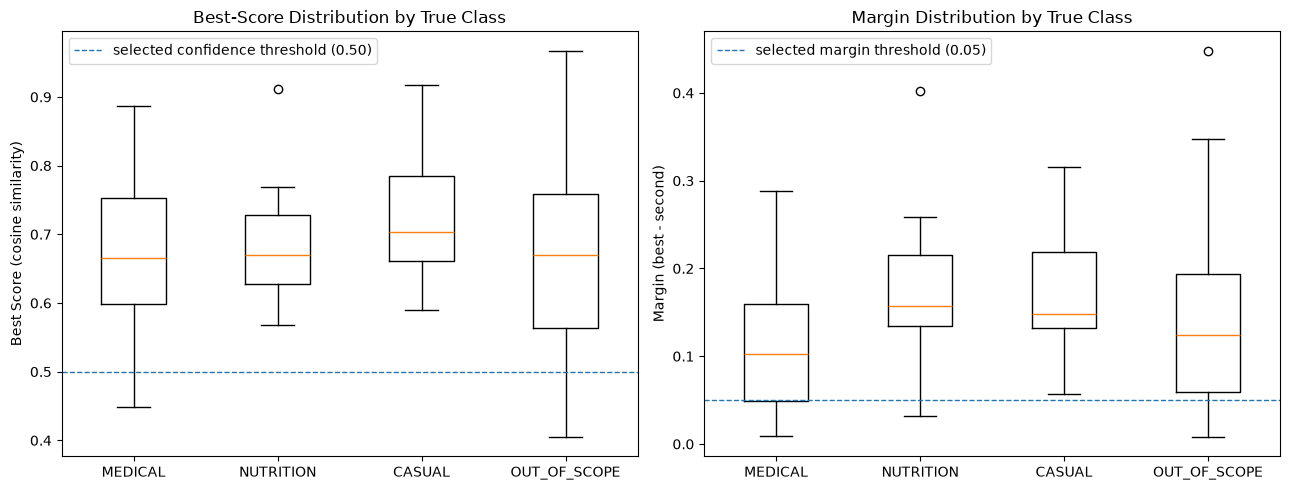

Score summary by class:
                 min       25%     50%       75%     max
True Label                                              
CASUAL        0.5899  0.660775  0.7031  0.784550  0.9169
MEDICAL       0.4487  0.598375  0.6661  0.753250  0.8873
NUTRITION     0.5682  0.627175  0.6695  0.727575  0.9112
OUT_OF_SCOPE  0.4048  0.563050  0.6700  0.759400  0.9674


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

data_by_class = [df_bench.loc[df_bench["True Label"] == lbl, "Score"] for lbl in labels_order]
axes[0].boxplot(data_by_class, tick_labels=labels_order)
axes[0].set_title("Best-Score Distribution by True Class")
axes[0].set_ylabel("Best Score (cosine similarity)")
axes[0].axhline(
    CONFIDENCE_THRESHOLD,
    linestyle="--",
    linewidth=1,
    label=f"selected confidence threshold ({CONFIDENCE_THRESHOLD:.2f})"
)
axes[0].legend()

margin_by_class = [df_bench.loc[df_bench["True Label"] == lbl, "Margin"] for lbl in labels_order]
axes[1].boxplot(margin_by_class, tick_labels=labels_order)
axes[1].set_title("Margin Distribution by True Class")
axes[1].set_ylabel("Margin (best - second)")
axes[1].axhline(
    MARGIN_THRESHOLD,
    linestyle="--",
    linewidth=1,
    label=f"selected margin threshold ({MARGIN_THRESHOLD:.2f})"
)
axes[1].legend()

plt.tight_layout()
plt.show()

print("Score summary by class:")
print(df_bench.groupby("True Label")["Score"].describe()[["min", "25%", "50%", "75%", "max"]])


## Regression Benchmark Test Script

In [3]:
import pandas as pd
from src.safety.scope_classifier import (
    BGEScopeClassifier,
    classify_scope_with_gate,
    CONFIDENCE_THRESHOLD,
    MARGIN_THRESHOLD,
)

print(f"⚙️ Active Constants:")
print(f"  • CONFIDENCE_THRESHOLD = {CONFIDENCE_THRESHOLD}")
print(f"  • MARGIN_THRESHOLD     = {MARGIN_THRESHOLD}\n")

# Initialize Classifier
classifier = BGEScopeClassifier()

# Quick regression suite for critical scope-routing cases
REGRESSION_SUITE = [
    # 1. Critical clinical follow-up
    ("What are the possible treatments for this?", "MEDICAL", True),
    ("What do you recommend for it?", "MEDICAL", True),

    # 2. Ambiguous follow-up with clinical context
    ("How can I make it better?", "MEDICAL", True),
    ("What should I do?", "MEDICAL", True),

    # 3. Technical / creative boundary
    ("Write Python code to analyze hives.", "OUT_OF_SCOPE", None),
    ("Generate HTML for this diagnosis.", "OUT_OF_SCOPE", True),

    # 4. Nutrition
    ("What should I eat?", "NUTRITION", None),

    # 5. Normal medical query
    ("What are the treatment options for psoriasis?", "MEDICAL", None),
]
results = []

for query, expected_scope, test_subject in REGRESSION_SUITE:
    # Test WITHOUT context first
    res_no_ctx = classify_scope_with_gate(classifier, query, clinical_subject=None)
    
    # Test WITH context if applicable
    res_with_ctx = classify_scope_with_gate(classifier, query, clinical_subject="scaly skin lesion") if test_subject else res_no_ctx

    results.append({
        "Query": query,
        "Expected": expected_scope,
        "BGE Best": res_no_ctx["best_scope"],
        "BGE Score": res_no_ctx["best_score"],
        "Margin": res_no_ctx["margin"],
        "Decision": res_no_ctx["decision"],
        "Scope (No Context)": res_no_ctx["scope"],
        "Scope (With Context)": res_with_ctx["scope"],
        "Source": res_with_ctx["scope_source"],
        "Pass": res_with_ctx["scope"] == expected_scope,
    })

df_reg = pd.DataFrame(results)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)

print(f"✅ Pass Rate: {df_reg['Pass'].mean():.2%}\n")
display(df_reg)

⚙️ Active Constants:
  • CONFIDENCE_THRESHOLD = 0.5
  • MARGIN_THRESHOLD     = 0.05

🔍 Initializing embedding model: BAAI/bge-large-en-v1.5
🔧 Using device: auto


Loading weights: 100%|██████████| 391/391 [00:00<00:00, 3271.91it/s]


✅ Pass Rate: 100.00%



,Query,Expected,BGE Best,BGE Score,Margin,Decision,Scope (No Context),Scope (With Context),Source,Pass
0,What are the possible treatments for this?,MEDICAL,MEDICAL,0.9058,0.2590,HIGH_CONFIDENCE,MEDICAL,MEDICAL,ANAPHORA_CONTEXT_OVERRIDE,True
1,What do you recommend for it?,MEDICAL,CASUAL,0.7153,0.0771,HIGH_CONFIDENCE,CASUAL,MEDICAL,ANAPHORA_CONTEXT_OVERRIDE,True
2,How can I make it better?,MEDICAL,NUTRITION,0.6958,0.0308,FALLBACK_ROUTED,CASUAL,MEDICAL,ANAPHORA_CONTEXT_OVERRIDE,True
3,What should I do?,MEDICAL,CASUAL,0.7683,0.0422,FALLBACK_ROUTED,CASUAL,MEDICAL,DIALOG_CONTEXT,True
4,Write Python code to analyze hives.,OUT_OF_SCOPE,OUT_OF_SCOPE,0.6867,0.1818,HIGH_CONFIDENCE,OUT_OF_SCOPE,OUT_OF_SCOPE,TECHNICAL_OVERRIDE,True
5,Generate HTML for this diagnosis.,OUT_OF_SCOPE,OUT_OF_SCOPE,0.6366,0.0181,HIGH_CONFIDENCE,OUT_OF_SCOPE,OUT_OF_SCOPE,TECHNICAL_OVERRIDE,True
6,What should I eat?,NUTRITION,NUTRITION,0.7867,0.1240,HIGH_CONFIDENCE,NUTRITION,NUTRITION,BGE,True
7,What are the treatment options for psoriasis?,MEDICAL,MEDICAL,0.7698,0.2528,HIGH_CONFIDENCE,MEDICAL,MEDICAL,BGE,True
